In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("MetroPT3(AirCompressor).csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(1516948, 17)
['Unnamed: 0', 'timestamp', 'TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']


,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [5]:
df = df.drop(columns=['Unnamed: 0'])
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(df['timestamp'].min(), df['timestamp'].max())

2020-02-01 00:00:00 2020-09-01 03:59:50


In [13]:
df.isnull().sum()

timestamp          0
TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         0
Oil_temperature    0
Motor_current      0
COMP               0
DV_eletric         0
Towers             0
MPG                0
LPS                0
Pressure_switch    0
Oil_level          0
Caudal_impulses    0
dtype: int64

In [6]:
continuous_cols = ['TP2','TP3','H1','DV_pressure','Reservoirs','Oil_temperature','Motor_current']
df[continuous_cols].describe()

,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current
count,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06
mean,1.367826e+00,8.984611e+00,7.568155e+00,5.595619e-02,8.985233e+00,6.264418e+01,2.050171e+00
std,3.250930e+00,6.390951e-01,3.333200e+00,3.824015e-01,6.383070e-01,6.516261e+00,2.302053e+00
min,-3.200000e-02,7.300000e-01,-3.600000e-02,-3.200000e-02,7.120000e-01,1.540000e+01,2.000000e-02
25%,-1.400000e-02,8.492000e+00,8.254000e+00,-2.200000e-02,8.494000e+00,5.777500e+01,4.000000e-02
50%,-1.200000e-02,8.960000e+00,8.784000e+00,-2.000000e-02,8.960000e+00,6.270000e+01,4.500000e-02
75%,-1.000000e-02,9.492000e+00,9.374000e+00,-1.800000e-02,9.492000e+00,6.725000e+01,3.807500e+00
max,1.067600e+01,1.030200e+01,1.028800e+01,9.844000e+00,1.030000e+01,8.905000e+01,9.295000e+00


In [7]:
digital_cols = ['COMP','DV_eletric','Towers','MPG','LPS','Pressure_switch','Oil_level','Caudal_impulses']
for col in digital_cols:
    print(col, df[col].value_counts())

COMP COMP
1.0    1269620
0.0     247328
Name: count, dtype: int64
DV_eletric DV_eletric
0.0    1273310
1.0     243638
Name: count, dtype: int64
Towers Towers
1.0    1395362
0.0     121586
Name: count, dtype: int64
MPG MPG
1.0    1263108
0.0     253840
Name: count, dtype: int64
LPS LPS
0.0    1511760
1.0       5188
Name: count, dtype: int64
Pressure_switch Pressure_switch
1.0    1503958
0.0      12990
Name: count, dtype: int64
Oil_level Oil_level
1.0    1371557
0.0     145391
Name: count, dtype: int64
Caudal_impulses Caudal_impulses
1.0    1421542
0.0      95406
Name: count, dtype: int64


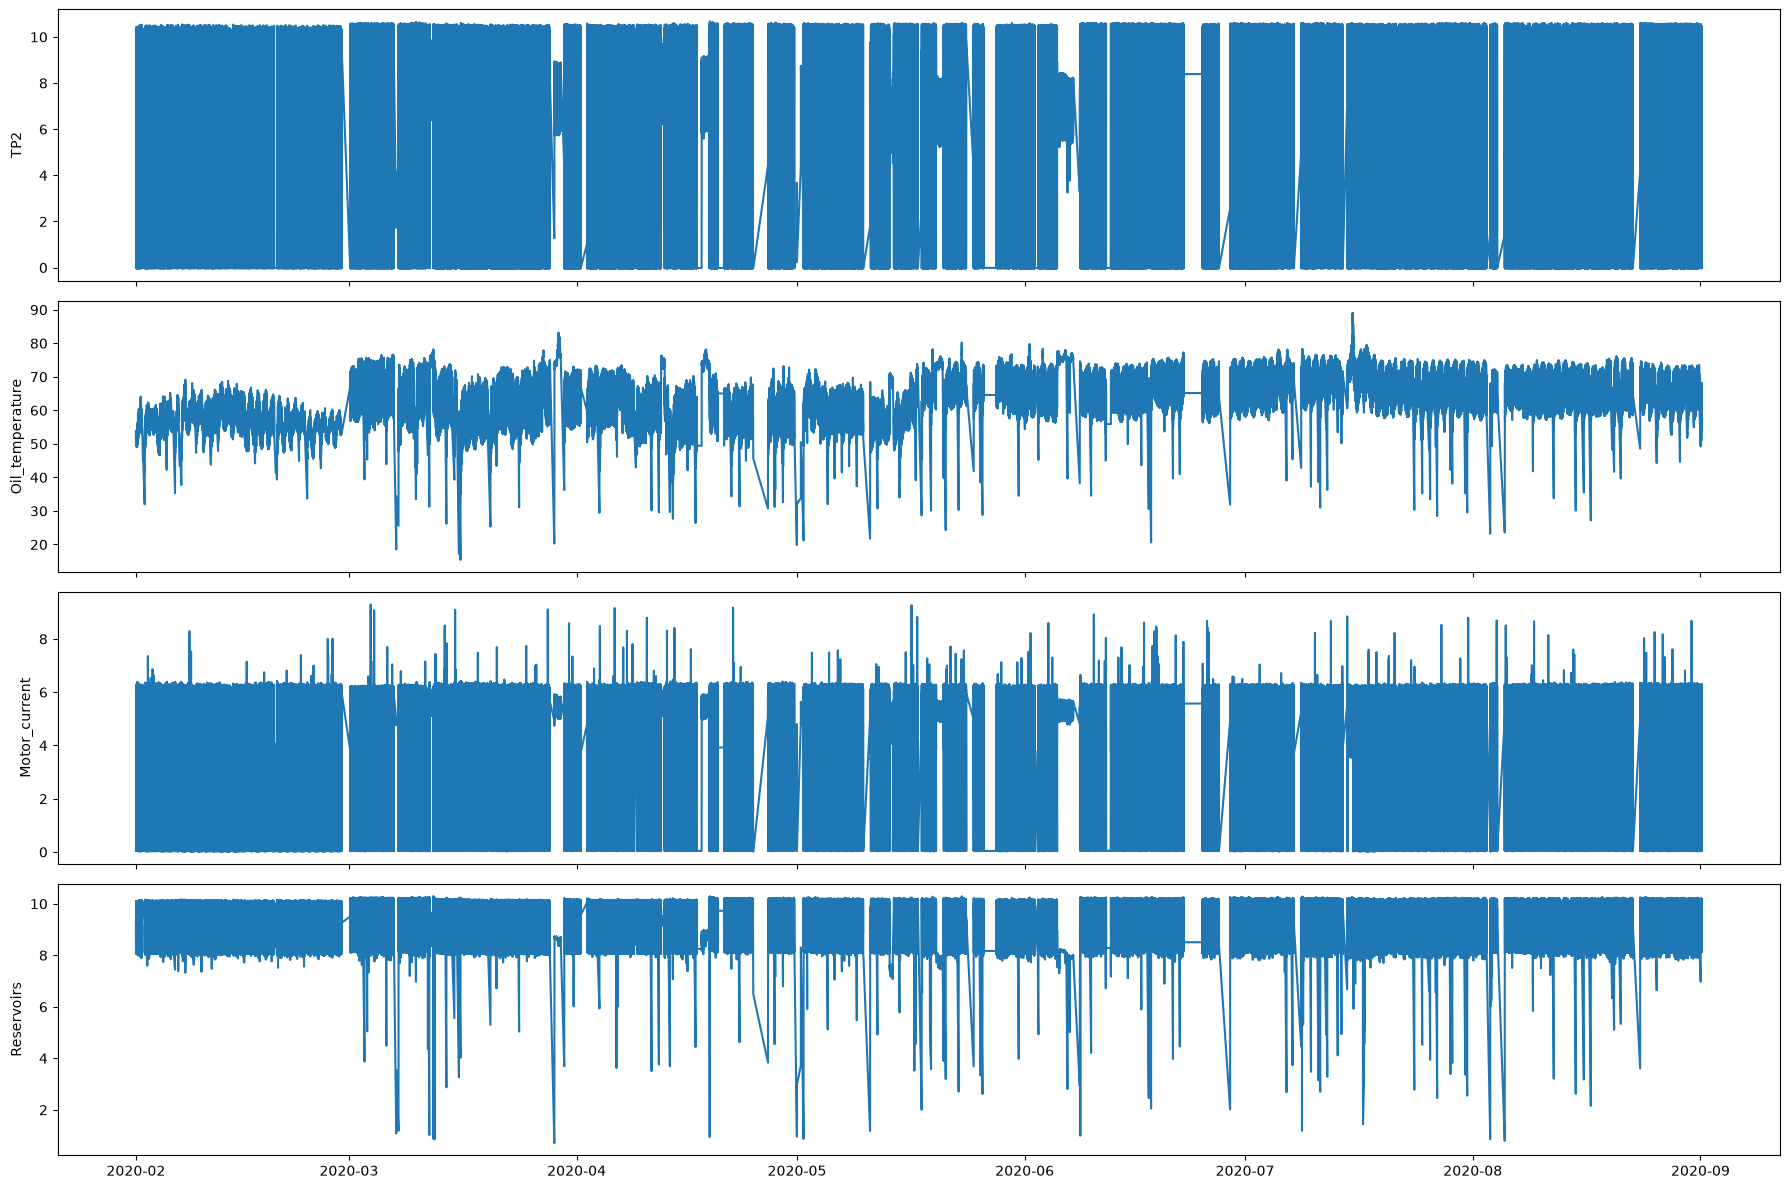

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)
axes[0].plot(df['timestamp'], df['TP2'])
axes[0].set_ylabel('TP2')
axes[1].plot(df['timestamp'], df['Oil_temperature'])
axes[1].set_ylabel('Oil_temperature')
axes[2].plot(df['timestamp'], df['Motor_current'])
axes[2].set_ylabel('Motor_current')
axes[3].plot(df['timestamp'], df['Reservoirs'])
axes[3].set_ylabel('Reservoirs')
plt.tight_layout()
plt.savefig('sensor_overview.png', dpi=100)

In [19]:
df_hourly = df.set_index('timestamp').resample('1h').mean().reset_index()

In [9]:
failures = [
    ('2020-04-18 00:00', '2020-04-18 23:59'),
    ('2020-05-29 23:30', '2020-05-30 06:00'),
    ('2020-06-05 10:00', '2020-06-07 14:30'),
    ('2020-07-15 14:30', '2020-07-15 19:00'),
]

df['label'] = 0
for start, end in failures:
    mask = (df['timestamp'] >= start) & (df['timestamp'] <= end)
    df.loc[mask, 'label'] = 1

print(df['label'].value_counts())

label
0    1486994
1      29954
Name: count, dtype: int64


In [11]:

sensors = ['TP2','TP3','H1','DV_pressure','Reservoirs','Oil_temperature','Motor_current']

for start, end, name in failures:
    start_ts = pd.Timestamp(start) - pd.Timedelta(hours=6)
    end_ts = pd.Timestamp(end) + pd.Timedelta(hours=6)
    window = df[(df['timestamp'] >= start_ts) & (df['timestamp'] <= end_ts)]

    fig, axes = plt.subplots(len(sensors), 1, figsize=(16, 14), sharex=True)
    for i, s in enumerate(sensors):
        axes[i].plot(window['timestamp'], window[s])
        axes[i].axvspan(pd.Timestamp(start), pd.Timestamp(end), color='red', alpha=0.2)
        axes[i].set_ylabel(s)
    axes[0].set_title(name)
    plt.tight_layout()
    plt.savefig(f'{name.replace(" ","_")}.png', dpi=100)
    plt.close()
    print(f"Saved {name.replace(' ','_')}.png")

Saved Failure_1.png
Saved Failure_2.png
Saved Failure_3.png
Saved Failure_4.png


In [13]:
summary_rows = []
for start, end, name in failures:
    fail_window = df[(df['timestamp'] >= start) & (df['timestamp'] <= end)]
    before_window = df[(df['timestamp'] >= pd.Timestamp(start) - pd.Timedelta(hours=6)) &
                        (df['timestamp'] < start)]
    for s in sensors:
        b_mean, b_std = before_window[s].mean(), before_window[s].std()
        d_mean = fail_window[s].mean()
        # z-score style shift: how many "normal std devs" did the mean move?
        shift = (d_mean - b_mean) / b_std if b_std > 0 else float('nan')
        summary_rows.append({'failure': name, 'sensor': s, 'before_mean': round(b_mean,3),
                              'during_mean': round(d_mean,3), 'before_std': round(b_std,3),
                              'shift_in_stds': round(shift,2)})

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df.to_csv('failure_sensor_summary.csv', index=False)

  failure          sensor  before_mean  during_mean  before_std  shift_in_stds
Failure 1             TP2       -0.018        8.518       0.000            NaN
Failure 1             TP3        8.248        8.812       0.000   1.586796e+14
Failure 1              H1        8.238        0.079       0.000            NaN
Failure 1     DV_pressure       -0.024        1.879       0.000   2.742284e+17
Failure 1      Reservoirs        8.248        8.813       0.000   1.589861e+14
Failure 1 Oil_temperature       49.450       74.131       0.000   3.472589e+15
Failure 1   Motor_current        0.040        5.604       0.000   8.016867e+17
Failure 2             TP2        1.261        8.175       3.155   2.190000e+00
Failure 2             TP3        8.970        8.402       0.569  -1.000000e+00
Failure 2              H1        7.655        0.071       3.196  -2.370000e+00
Failure 2     DV_pressure        0.080        1.925       0.441   4.180000e+00
Failure 2      Reservoirs        8.971        8.404 

In [18]:
window = 60  # ~10 minutes at 10s sampling — adjust after seeing results

sensors = ['TP2','TP3','H1','DV_pressure','Reservoirs','Oil_temperature','Motor_current']

df = df.sort_values('timestamp').reset_index(drop=True)

for s in sensors:
    df[f'{s}_roll_std'] = df[s].rolling(window, min_periods=1).std()
    df[f'{s}_roll_range'] = (df[s].rolling(window, min_periods=1).max()
                              - df[s].rolling(window, min_periods=1).min())
    df[f'{s}_roll_mean'] = df[s].rolling(window, min_periods=1).mean()

In [15]:
# Count how many times H1 crosses a low threshold within the rolling window
# (proxy for "is the compressor still cutting off normally")
threshold = 1.0
df['H1_low'] = (df['H1'] < threshold).astype(int)
df['H1_cycle_transitions'] = df['H1_low'].diff().abs().rolling(window, min_periods=1).sum()

In [16]:
for s in ['Oil_temperature','Motor_current','TP3','Reservoirs']:
    df[f'{s}_diff'] = df[s].diff()
    df[f'{s}_roll_trend'] = df[s].rolling(window, min_periods=1).mean().diff()

In [17]:
check_cols = ['H1_roll_std','H1_cycle_transitions','Oil_temperature_roll_trend']
sample_fail = df[(df['timestamp'] >= '2020-06-05 10:00') & (df['timestamp'] <= '2020-06-07 14:30')]
sample_normal = df[(df['timestamp'] >= '2020-06-01 00:00') & (df['timestamp'] <= '2020-06-01 06:00')]

print("FAILURE window:\n", sample_fail[check_cols].describe())
print("\nNORMAL window:\n", sample_normal[check_cols].describe())

FAILURE window:
         H1_roll_std  H1_cycle_transitions  Oil_temperature_roll_trend
count  17315.000000               17315.0                17315.000000
mean       0.001209                   0.0                    0.000142
std        0.000331                   0.0                    0.026726
min        0.000573                   0.0                   -0.604167
25%        0.000994                   0.0                   -0.001667
50%        0.001110                   0.0                    0.000417
75%        0.001346                   0.0                    0.002917
max        0.002585                   0.0                    0.452500

NORMAL window:
        H1_roll_std  H1_cycle_transitions  Oil_temperature_roll_trend
count  1986.000000           1986.000000                 1986.000000
mean      1.791292              0.850957                   -0.001024
std       1.687782              1.002738                    0.113147
min       0.211965              0.000000                   -

In [19]:
check_cols = ['H1_roll_std', 'H1_cycle_transitions']

failure_windows = [
    ('2020-04-18 00:00', '2020-04-18 23:59', 'Failure 1'),
    ('2020-05-29 23:30', '2020-05-30 06:00', 'Failure 2'),
    ('2020-06-05 10:00', '2020-06-07 14:30', 'Failure 3'),
    ('2020-07-15 14:30', '2020-07-15 19:00', 'Failure 4'),
]

# Use a verified-active normal window for each (a few days before each failure,
# picked to avoid idle periods)
normal_windows = [
    ('2020-04-15 00:00', '2020-04-15 06:00'),
    ('2020-05-26 00:00', '2020-05-26 06:00'),
    ('2020-06-01 00:00', '2020-06-01 06:00'),
    ('2020-07-12 00:00', '2020-07-12 06:00'),
]

for (f_start, f_end, name), (n_start, n_end) in zip(failure_windows, normal_windows):
    fail = df[(df['timestamp'] >= f_start) & (df['timestamp'] <= f_end)]
    normal = df[(df['timestamp'] >= n_start) & (df['timestamp'] <= n_end)]
    
    print(f"\n=== {name} ===")
    print("Normal H1_roll_std mean:", round(normal['H1_roll_std'].mean(), 4),
          "| H1_cycle_transitions mean:", round(normal['H1_cycle_transitions'].mean(), 4))
    print("Failure H1_roll_std mean:", round(fail['H1_roll_std'].mean(), 4),
          "| H1_cycle_transitions mean:", round(fail['H1_cycle_transitions'].mean(), 4))


=== Failure 1 ===
Normal H1_roll_std mean: 1.4587 | H1_cycle_transitions mean: 0.8428
Failure H1_roll_std mean: 0.0239 | H1_cycle_transitions mean: 0.0069

=== Failure 2 ===
Normal H1_roll_std mean: 4.7215 | H1_cycle_transitions mean: 1.0
Failure H1_roll_std mean: 0.0293 | H1_cycle_transitions mean: 0.0081

=== Failure 3 ===
Normal H1_roll_std mean: 1.7913 | H1_cycle_transitions mean: 0.851
Failure H1_roll_std mean: 0.0012 | H1_cycle_transitions mean: 0.0

=== Failure 4 ===
Normal H1_roll_std mean: 2.9369 | H1_cycle_transitions mean: 1.1958
Failure H1_roll_std mean: 0.1788 | H1_cycle_transitions mean: 0.0549
